In [1]:
from langgraph.graph import MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
model =   ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")


In [4]:
class ChatState(MessagesState):
    summary: str

In [5]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [6]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [7]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [8]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [9]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

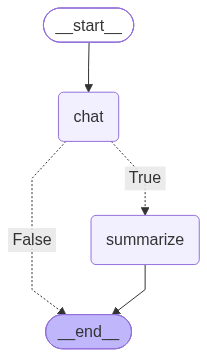

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [12]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [13]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='9ee48d85-6b9b-4e21-b3b3-d81b240e6958')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : [{'type': 'text', 'text': 'Quantum physics (or quantum mechanics) is the branch of science that describes the behavior of the universe at the smallest possible scales—atoms, electrons, photons, and subatomic particles.\n\nAt this level, the rules of "classical" physics (the physics of everyday objects like balls, cars, and planets) break down entirely. Instead of predictable paths, we enter a world of probability, uncertainty, and strange interconnectedness.\n\nHere are the core concepts that define quantum physics:\n\n---\n\n### 1. Wave-Particle Duality\nIn our everyday world, things are either particles (solid objects) or waves (ripples in a pond). In the quantum world, everything behaves like both.\n*   **The Double-Slit Experiment:** When you fire electrons a

In [14]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='9ee48d85-6b9b-4e21-b3b3-d81b240e6958'), AIMessage(content=[{'type': 'text', 'text': 'Quantum physics (or quantum mechanics) is the branch of science that describes the behavior of the universe at the smallest possible scales—atoms, electrons, photons, and subatomic particles.\n\nAt this level, the rules of "classical" physics (the physics of everyday objects like balls, cars, and planets) break down entirely. Instead of predictable paths, we enter a world of probability, uncertainty, and strange interconnectedness.\n\nHere are the core concepts that define quantum physics:\n\n---\n\n### 1. Wave-Particle Duality\nIn our everyday world, things are either particles (solid objects) or waves (ripples in a pond). In the quantum world, everything behaves like both.\n*   **The Double-Slit Experiment:** When you fire electrons at two slits, they form an interference pattern—a signature of waves—even if you 

In [15]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='9ee48d85-6b9b-4e21-b3b3-d81b240e6958'), AIMessage(content=[{'type': 'text', 'text': 'Quantum physics (or quantum mechanics) is the branch of science that describes the behavior of the universe at the smallest possible scales—atoms, electrons, photons, and subatomic particles.\n\nAt this level, the rules of "classical" physics (the physics of everyday objects like balls, cars, and planets) break down entirely. Instead of predictable paths, we enter a world of probability, uncertainty, and strange interconnectedness.\n\nHere are the core concepts that define quantum physics:\n\n---\n\n### 1. Wave-Particle Duality\nIn our everyday world, things are either particles (solid objects) or waves (ripples in a pond). In the quantum world, everything behaves like both.\n*   **The Double-Slit Experiment:** When you fire electrons at two slits, they form an interference pattern—a signature of waves—even if you 

In [16]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='9ee48d85-6b9b-4e21-b3b3-d81b240e6958'), AIMessage(content=[{'type': 'text', 'text': 'Quantum physics (or quantum mechanics) is the branch of science that describes the behavior of the universe at the smallest possible scales—atoms, electrons, photons, and subatomic particles.\n\nAt this level, the rules of "classical" physics (the physics of everyday objects like balls, cars, and planets) break down entirely. Instead of predictable paths, we enter a world of probability, uncertainty, and strange interconnectedness.\n\nHere are the core concepts that define quantum physics:\n\n---\n\n### 1. Wave-Particle Duality\nIn our everyday world, things are either particles (solid objects) or waves (ripples in a pond). In the quantum world, everything behaves like both.\n*   **The Double-Slit Experiment:** When you fire electrons at two slits, they form an interference pattern—a signature of waves—even if you 